In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecommerce-dataset/item_properties_part1.csv
/kaggle/input/ecommerce-dataset/category_tree.csv
/kaggle/input/ecommerce-dataset/item_properties_part2.csv
/kaggle/input/ecommerce-dataset/events.csv


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import TruncatedSVD

import math

EDA

ITEM

In [3]:
items_raw_df = pd.read_csv('/kaggle/input/ecommerce-dataset/item_properties_part1.csv')
items_raw1_df = pd.read_csv('/kaggle/input/ecommerce-dataset/item_properties_part2.csv')
items_raw_df = pd.concat([items_raw_df, items_raw1_df])
items_raw_df.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [4]:
print(
    f"""
    There are {items_raw_df['itemid'].nunique()} distinct items.
    There are {items_raw_df['property'].nunique()} distinct properties.
    """)


    There are 417053 distinct items.
    There are 1104 distinct properties.
    


In [5]:
# T0 make things run faster lets sample few items
np.random.seed(1)
items_to_keep = np.random.choice(items_raw_df['itemid'].unique(), size=100000, replace=False)
items_df = items_raw_df[items_raw_df['itemid'].isin(items_to_keep)]

In [6]:
print(
    f"""
    There are {items_df['itemid'].nunique()} distinct items.
    There are {items_df['property'].nunique()} distinct properties.
    """)


    There are 100000 distinct items.
    There are 1082 distinct properties.
    


In [7]:
# To simplify we will not take the changes over time. instead just use the last value.
items_df = items_df.groupby(['itemid', 'property'])['value'].last().to_frame().reset_index()
items_df

,itemid,property,value
0,3,1025,769062
1,3,1080,769062
2,3,112,679677
3,3,159,519769
4,3,202,261419
...,...,...,...
2879852,466864,888,1262739 205682 1050016
2879853,466864,917,205682
2879854,466864,928,1154859
2879855,466864,available,0


In [8]:
items_df['itemid'].value_counts().head()

itemid
175046    59
329126    56
397858    56
315300    56
51824     56
Name: count, dtype: int64

EVENT

In [9]:
events_raw_df = pd.read_csv('/kaggle/input/ecommerce-dataset/events.csv')

In [10]:
events_raw_df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [11]:
events_df = events_raw_df[events_raw_df['itemid'].isin(items_to_keep)]
events_df = events_df.sort_values(['visitorid', 'timestamp']).reset_index(drop=True)

In [12]:
events_df

,timestamp,visitorid,event,itemid,transactionid
0,1438970212664,2,view,259884,NaN
1,1438413035296,3,view,385090,NaN
2,1438713029611,10,view,248766,NaN
3,1430668212744,12,view,70225,NaN
4,1434602595136,13,view,278689,NaN
...,...,...,...,...,...
606569,1431311689814,1407572,view,122041,NaN
606570,1431738322384,1407572,view,122041,NaN
606571,1437973678632,1407573,view,116453,NaN
606572,1437973995037,1407573,view,57720,NaN


In [13]:
print(
    f"""
    There are {events_df['visitorid'].nunique()} distinct users in events.
    There are {events_df['transactionid'].nunique()} distinct transactions in events.
    There are {events_df['itemid'].nunique()} distinct items in events.
    The actions user can do are {events_df['event'].unique()}.
    """
)


    There are 375331 distinct users in events.
    There are 4995 distinct transactions in events.
    There are 44358 distinct items in events.
    The actions user can do are ['view' 'addtocart' 'transaction'].
    


In [14]:
print(
    f"""
    {events_df['event'].value_counts()},
    {events_df['event'].value_counts(normalize=True)}
    """
)


    event
view           584488
addtocart       16598
transaction      5488
Name: count, dtype: int64,
    event
view           0.963589
addtocart      0.027364
transaction    0.009048
Name: proportion, dtype: float64
    


In [15]:
print(
    f"""
    Most bought items: \n {events_df['itemid'].value_counts().head()},
    Most active users: \n{events_df['visitorid'].value_counts().head()}
    """
)


    Most bought items: 
 itemid
257040    1647
96924     1633
234255    1307
151444    1230
9877      1162
Name: count, dtype: int64,
    Most active users: 
visitorid
1150086    1722
530559      904
152963      737
895999      639
163561      594
Name: count, dtype: int64
    


In [16]:
events_df.dtypes

timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

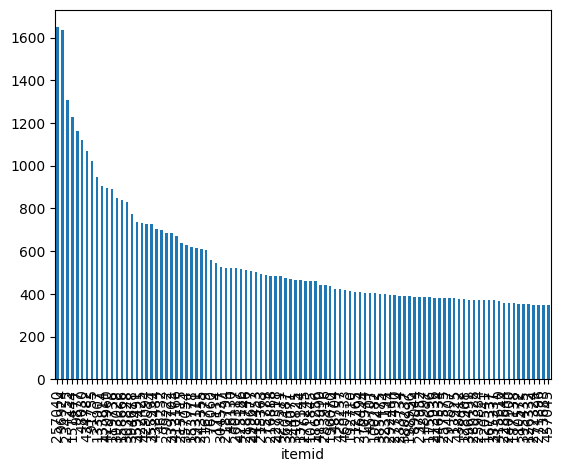

In [17]:
events_df['itemid'].astype(str).value_counts().head(100).plot.bar()
plt.show()

**POPULARTIES**

In [18]:
# Điều chỉnh trọng số
event_to_rating = {
    'view': 1.0,         # Giảm trọng số
    'addtocart': 2.0,    # Tăng trọng số
    'transaction': 3.0   # Trọng số cao nhất
}
events_df['rating'] = events_df['event'].map(event_to_rating)


# Xem dữ liệu sau khi thêm cột rating
print("\nDữ liệu sau khi thêm cột rating:")
print(events_df[['visitorid', 'itemid', 'event', 'rating']].head())


Dữ liệu sau khi thêm cột rating:
   visitorid  itemid event  rating
0          2  259884  view     1.0
1          3  385090  view     1.0
2         10  248766  view     1.0
3         12   70225  view     1.0
4         13  278689  view     1.0


In [19]:
popular_products = pd.DataFrame(events_df.groupby('itemid')['rating'].mean())
most_popular = popular_products.sort_values('rating', ascending=False)
most_popular.head(10)

,rating
itemid,
159562,2.500000
28789,2.428571
423963,2.000000
412238,2.000000
353048,2.000000
370140,2.000000
110428,2.000000
199279,2.000000
98310,2.000000


CONTENT

In [20]:
items_df

,itemid,property,value
0,3,1025,769062
1,3,1080,769062
2,3,112,679677
3,3,159,519769
4,3,202,261419
...,...,...,...
2879852,466864,888,1262739 205682 1050016
2879853,466864,917,205682
2879854,466864,928,1154859
2879855,466864,available,0


In [21]:
# 1 -> "769062 205682 1154859 373 1154859"
#items_df = items_df.groupby('itemid')['value'].apply(lambda x: ' '.join(x)).to_frame()

In [22]:
#items_df.head()

In [23]:
#tfidfvec = TfidfVectorizer(min_df=500, max_df=0.7)
#vectorized_data = tfidfvec.fit_transform(items_df['value'])

In [24]:
#vectorized_data

In [25]:
#tfidf_df = pd.DataFrame(vectorized_data.toarray(),
                       #columns=tfidfvec.get_feature_names_out())
#tfidf_df.index = items_df.index
#display(tfidf_df)

In [26]:
#cosine_similarity(tfidf_df.loc[3].values.reshape(1, -1),
                  #tfidf_df.loc[7].values.reshape(1, -1))

In [27]:
#import seaborn as sns
#import matplotlib.pyplot as plt
#import pandas as pd

# Convert sparse matrix to DataFrame for better visualization
#tfidf_df = pd.DataFrame(vectorized_data.toarray(), columns=tfidfvec.get_feature_names_out())

# Plot heatmap
#plt.figure(figsize=(10, 8))
#sns.heatmap(tfidf_df, cmap="YlGnBu", xticklabels=tfidf_df.columns, yticklabels=False, cbar=True)
#plt.title('Heatmap of TF-IDF Features')
#plt.xlabel('Terms')
#plt.ylabel('Items')
#plt.show()


In [28]:
items_raw_df.head

<bound method NDFrame.head of              timestamp  itemid    property                             value
0        1435460400000  460429  categoryid                              1338
1        1441508400000  206783         888           1116713 960601 n277.200
2        1439089200000  395014         400   n552.000 639502 n720.000 424566
3        1431226800000   59481         790                        n15360.000
4        1431831600000  156781         917                            828513
...                ...     ...         ...                               ...
9275898  1433646000000  236931         929                           n12.000
9275899  1440903600000  455746           6                     150169 639134
9275900  1439694000000  347565         686                            610834
9275901  1433646000000  287231         867                            769062
9275902  1442113200000  275768         888  888666 n10800.000 746840 1318567

[20275902 rows x 4 columns]>

In [29]:
# Chọn mẫu nhỏ để tăng tốc quá trình
np.random.seed(1)
items_to_keep = np.random.choice(items_raw_df['itemid'].unique(), size=10000, replace=False)
items_df = items_raw_df[items_raw_df['itemid'].isin(items_to_keep)]

# Chỉ lấy giá trị cuối cùng của từng thuộc tính sản phẩm
items_df = items_df.groupby(['itemid', 'property'])['value'].last().to_frame().reset_index()

# Nối các giá trị thuộc tính của mỗi sản phẩm thành một chuỗi
items_df = items_df.groupby('itemid')['value'].apply(lambda x: ' '.join(x)).to_frame()

# Vector hóa dữ liệu bằng TfidfVectorizer
tfidfvec = TfidfVectorizer(min_df=500, max_df=0.5)
vectorized_data = tfidfvec.fit_transform(items_df['value'])
print(f"Số đặc trưng trong dữ liệu: {vectorized_data.shape[1]}")



Số đặc trưng trong dữ liệu: 67


In [30]:
# Áp dụng TruncatedSVD để giảm chiều dữ liệu
n_components = 40  # Số lượng chiều sau khi giảm
svd = TruncatedSVD(n_components=n_components, random_state=1)
svd_data = svd.fit_transform(vectorized_data)
# 2. Ẩn 20% dữ liệu
test_size = int(0.2 * len(items_df))
test_items = np.random.choice(items_df.index, size=test_size, replace=False)
train_items = list(set(items_df.index) - set(test_items))
# Tạo DataFrame với dữ liệu đã giảm chiều
svd_df = pd.DataFrame(svd_data)
svd_df.index = items_df.index

# Hàm tính cosine similarity giữa các sản phẩm đã giảm chiều
def get_similar_items_svd(item_id, top_n=10):
    # Tính cosine similarity giữa sản phẩm nhập vào và tất cả các sản phẩm khác
    item_vector = svd_df.loc[item_id].values.reshape(1, -1)
    similarity_scores = cosine_similarity(item_vector, svd_df.values).flatten()
    
    # Lọc sản phẩm tương tự
    similar_items = similarity_scores.argsort()[-top_n-1:-1][::-1]
    return svd_df.index[similar_items], similarity_scores[similar_items]

# Hàm tính RMSE
def calculate_rmse(true_similarities, predicted_similarities):
    return np.sqrt(mean_squared_error(true_similarities, predicted_similarities))

# Hàm tính F-score@K
def calculate_fscore_at_k(true_items, predicted_items, k=5):
    relevant = set(true_items) & set(predicted_items[:k])
    return len(relevant) / k



# 3. Dự đoán và đánh giá mô hình
rmse_scores = []
f_scores = []

# Kiểm tra trên 20% dữ liệu ẩn
for item_id in test_items:
    true_similar_items, true_similarities = get_similar_items_svd(item_id, top_n=10)  # Lấy sản phẩm tương tự thực tế
    predicted_similar_items, predicted_similarities = get_similar_items_svd(item_id, top_n=10)  # Dự đoán các sản phẩm tương tự
    
    # Tính RMSE giữa điểm tương đồng thực tế và điểm tương đồng dự đoán
    rmse = calculate_rmse(true_similarities, predicted_similarities)
    fscore = calculate_fscore_at_k(true_similar_items, predicted_similar_items, k=5)
    
    rmse_scores.append(rmse)
    f_scores.append(fscore)

# In kết quả đánh giá
print(f"RMSE: {np.mean(rmse_scores):.4f}")
print(f"F-score: {np.mean(f_scores):.4f}")
print(predicted_similar_items)

RMSE: 0.0000
F-score: 1.0000
Index([94503, 87391, 372751, 178129, 427683, 450917, 370809, 390528, 180306,
       12179],
      dtype='int64', name='itemid')


5 sản phẩm tương tự cho sản phẩm với itemid 176671:
1. Sản phẩm itemid 374067 với độ tương đồng: 1.0000
2. Sản phẩm itemid 329166 với độ tương đồng: 0.9320
3. Sản phẩm itemid 221825 với độ tương đồng: 0.9174
4. Sản phẩm itemid 68895 với độ tương đồng: 0.8843
5. Sản phẩm itemid 385718 với độ tương đồng: 0.8843


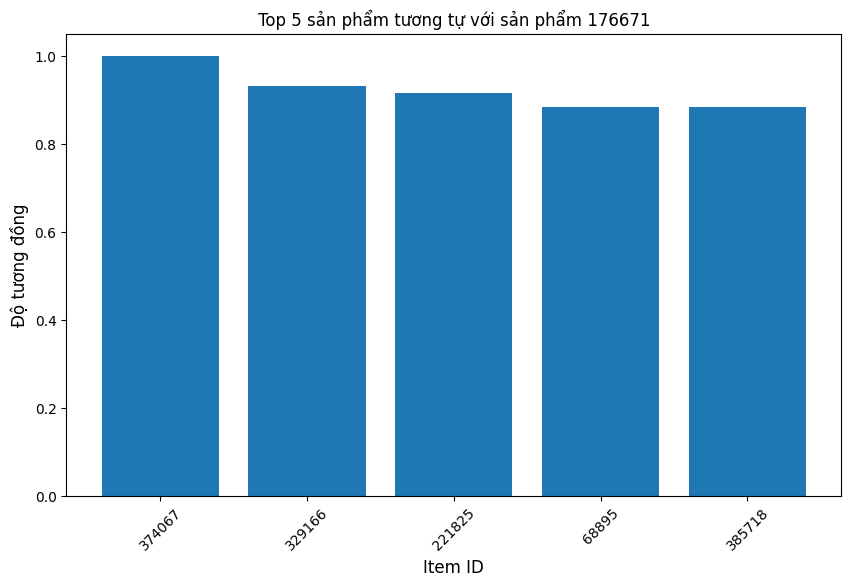

In [31]:
import numpy as np

# Chọn ngẫu nhiên một item_id từ tập dữ liệu items_df
#random_item_id = np.random.choice(items_df.index)

# Hiển thị item_id đã chọn ngẫu nhiên
#print(f"Item ID ngẫu nhiên được chọn: {random_item_id}")
# Lấy các sản phẩm tương tự cho item_id ngẫu nhiên
similar_items, similarity_scores = get_similar_items_svd(item_id=176671, top_n=5)

# Hiển thị kết quả gợi ý
print(f"5 sản phẩm tương tự cho sản phẩm với itemid 176671:")
for i, item in enumerate(similar_items):
    print(f"{i+1}. Sản phẩm itemid {item} với độ tương đồng: {similarity_scores[i]:.4f}")
# Vẽ biểu đồ bar để trực quan hóa độ tương đồng
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), similarity_scores, tick_label=similar_items)
plt.xlabel('Item ID', fontsize=12)
plt.ylabel('Độ tương đồng', fontsize=12)
plt.title(f"Top 5 sản phẩm tương tự với sản phẩm 176671", fontsize=12)
plt.xticks(rotation=45)
plt.show()

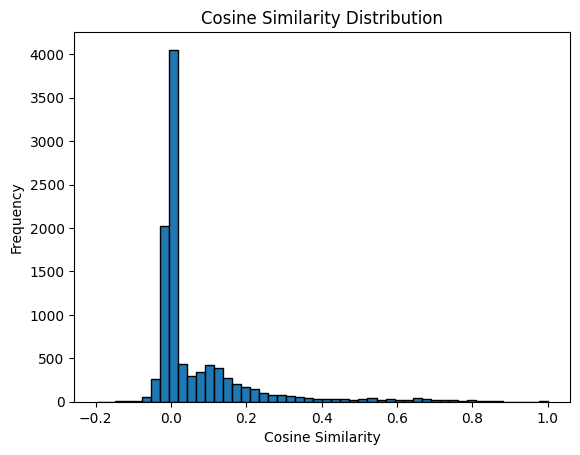

Top 5 cosine similarities for item 321321: [1.0, 1.0, 1.0, 1.0, 1.0]


In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Kiểm tra phân phối của cosine similarity giữa một sản phẩm và tất cả các sản phẩm khác
item_id = test_items[0]  # Lấy sản phẩm đầu tiên trong bộ test
item_vector = svd_df.loc[item_id].values.reshape(1, -1)
similarity_scores = cosine_similarity(item_vector, svd_df.values).flatten()

# Vẽ biểu đồ phân phối cosine similarity
plt.hist(similarity_scores, bins=50, edgecolor='black')
plt.title('Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

# In ra một số giá trị cosine similarity
print(f"Top 5 cosine similarities for item {item_id}: {sorted(similarity_scores, reverse=True)[:5]}")


collab

In [33]:
# Lọc người dùng với ít nhất 5 tương tác
user_counts = events_df['visitorid'].value_counts()
active_users = user_counts[user_counts >= 5].index
filtered_events = events_df[events_df['visitorid'].isin(active_users)]

# Lọc sản phẩm với ít nhất 10 tương tác
item_counts = filtered_events['itemid'].value_counts()
popular_items = item_counts[item_counts >= 10].index
filtered_events = filtered_events[filtered_events['itemid'].isin(popular_items)]

# Xem dữ liệu sau khi lọc
print("\nSố lượng người dùng và sản phẩm sau khi lọc:")
print("Số người dùng:", filtered_events['visitorid'].nunique())
print("Số sản phẩm:", filtered_events['itemid'].nunique())


Số lượng người dùng và sản phẩm sau khi lọc:
Số người dùng: 11151
Số sản phẩm: 3507


In [34]:
from scipy.sparse import csr_matrix
# Mã hóa user và item
filtered_events['user_idx'] = filtered_events['visitorid'].astype('category').cat.codes
filtered_events['item_idx'] = filtered_events['itemid'].astype('category').cat.codes


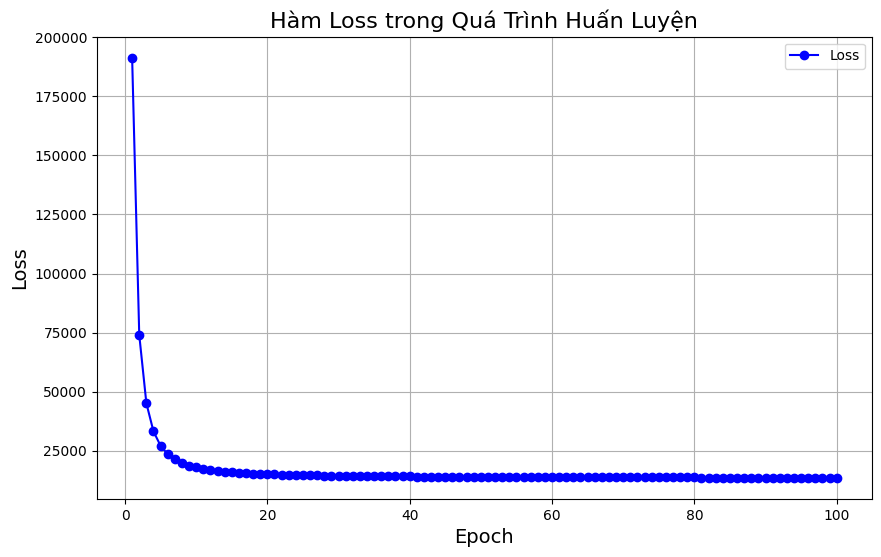

In [35]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Giả sử filtered_events là DataFrame đã được chuẩn bị với user_idx, item_idx, rating

# Bước 1: Huấn luyện mô hình trên toàn bộ dữ liệu 
sparse_matrix = csr_matrix((filtered_events['rating'], (filtered_events['user_idx'], filtered_events['item_idx'])))
num_users, num_items = sparse_matrix.shape
num_latent_factors = 50  # Số lượng yếu tố tiềm ẩn
learning_rate = 0.01  # Học tỷ lệ
regularization = 0.1  # Hệ số điều chuẩn (regularization)
num_epochs = 100 # Số vòng lặp huấn luyện

# Khởi tạo ngẫu nhiên ma trận người dùng và sản phẩm
user_matrix = np.random.rand(num_users, num_latent_factors)
item_matrix = np.random.rand(num_items, num_latent_factors)

# Hàm tính toán lỗi (loss) và Gradient Descent

def matrix_factorization(sparse_matrix, user_matrix, item_matrix, learning_rate, regularization, num_epochs):
    loss_list = []  # Danh sách lưu giá trị loss sau mỗi epoch
    
    for epoch in range(num_epochs):
        # Gradient Descent để cập nhật ma trận người dùng và sản phẩm
        for user_idx, item_idx, rating in zip(filtered_events['user_idx'], filtered_events['item_idx'], filtered_events['rating']):
            # Dự đoán rating
            pred = np.dot(user_matrix[user_idx], item_matrix[item_idx])
            
            # Tính lỗi (error)
            error = rating - pred
            
            # Cập nhật ma trận người dùng và sản phẩm
            user_matrix[user_idx] += learning_rate * (error * item_matrix[item_idx] - regularization * user_matrix[user_idx])
            item_matrix[item_idx] += learning_rate * (error * user_matrix[user_idx] - regularization * item_matrix[item_idx])
        
        # Tính loss sau mỗi epoch
        loss = 0
        for user_idx, item_idx, rating in zip(filtered_events['user_idx'], filtered_events['item_idx'], filtered_events['rating']):
            pred = np.dot(user_matrix[user_idx], item_matrix[item_idx])
            loss += (rating - pred) ** 2
        loss += regularization * (np.linalg.norm(user_matrix) + np.linalg.norm(item_matrix))
        
        loss_list.append(loss)  # Lưu loss vào danh sách
        

    return user_matrix, item_matrix, loss_list

# Huấn luyện mô hình trên toàn bộ dữ liệu và lấy giá trị loss
user_matrix, item_matrix, loss_list = matrix_factorization(sparse_matrix, user_matrix, item_matrix, learning_rate, regularization, num_epochs)

# Vẽ biểu đồ loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), loss_list, label='Loss', color='blue', marker='o')
plt.title('Hàm Loss trong Quá Trình Huấn Luyện', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

In [36]:
# Bước 2: Ẩn một số dữ liệu để tạo test set
# Tạo test set bằng cách ẩn 20% dữ liệu
train_data, test_data = train_test_split(filtered_events, test_size=0.2)

In [37]:
# Bước 3: Dự đoán rating trên tập kiểm tra
predictions = []
actual = []

# Dự đoán cho từng user_idx, item_idx trong test set
for _, row in test_data.iterrows():
    user_idx = row['user_idx']
    item_idx = row['item_idx']
    
    # Dự đoán rating
    pred = np.dot(user_matrix[user_idx], item_matrix[item_idx].T)
    
    predictions.append(pred)
    actual.append(row['rating'])

In [38]:
# Bước 4: Đánh giá mô hình
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
print(f"MSE trên tập kiểm tra: {mse}")
print(f"RMSE trên tập kiểm tra: {rmse}")

MSE trên tập kiểm tra: 0.13947434295820563
RMSE trên tập kiểm tra: 0.37346263930707396


In [39]:
import pandas as pd

# Tạo DataFrame để hiển thị kết quả giữa thực tế và dự đoán
results = pd.DataFrame({
    'user_idx': test_data['user_idx'],
    'item_idx': test_data['item_idx'],
    'Actual Rating': actual,
    'Predicted Rating': predictions
})

# Hiển thị kết quả
print(results.head(10))  # Hiển thị 10 dòng đầu tiên

        user_idx  item_idx  Actual Rating  Predicted Rating
538468      9899      2542            1.0          1.479428
208843      3871      1279            1.0          0.935127
439425      8107      3494            1.0          1.182703
143427      2639      3336            3.0          1.807659
216153      4003      2214            1.0          0.964370
60222       1122      2061            1.0          1.030915
568234     10449      3082            1.0          0.971182
388132      7168      1640            1.0          0.810727
415466      7653       494            1.0          0.961273
206227      3826      1253            1.0          1.385207


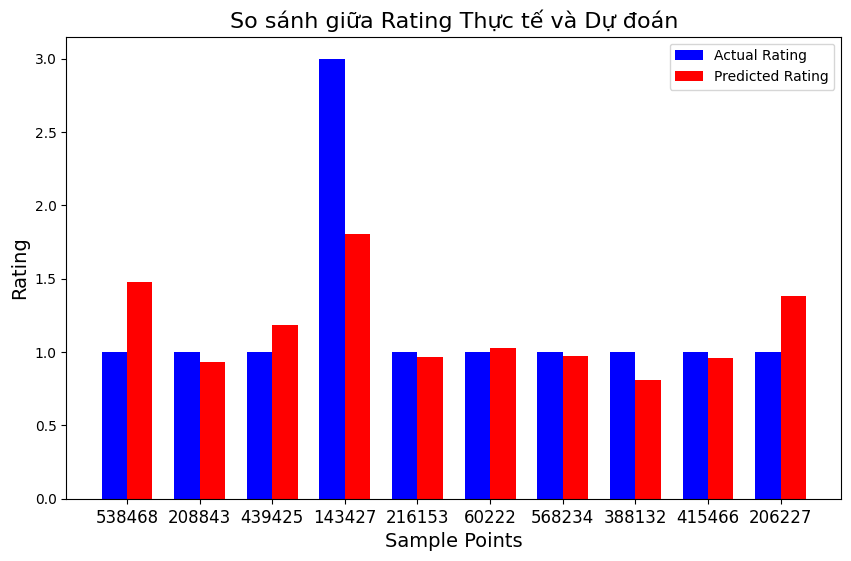

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Chọn 10 dòng đầu tiên từ kết quả
top_10_results = results.head(10)

# Vẽ biểu đồ cột
bar_width = 0.35
index = np.arange(len(top_10_results))

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ cột cho 'Actual Rating' và 'Predicted Rating'
bar1 = ax.bar(index, top_10_results['Actual Rating'], bar_width, label='Actual Rating', color='b')
bar2 = ax.bar(index + bar_width, top_10_results['Predicted Rating'], bar_width, label='Predicted Rating', color='r')

# Thêm tiêu đề, nhãn, và xếp trục
ax.set_xlabel('Sample Points', fontsize=14)
ax.set_ylabel('Rating', fontsize=14)
ax.set_title('So sánh giữa Rating Thực tế và Dự đoán', fontsize=16)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(top_10_results.index, fontsize=12)
ax.legend()

# Hiển thị biểu đồ
plt.show()


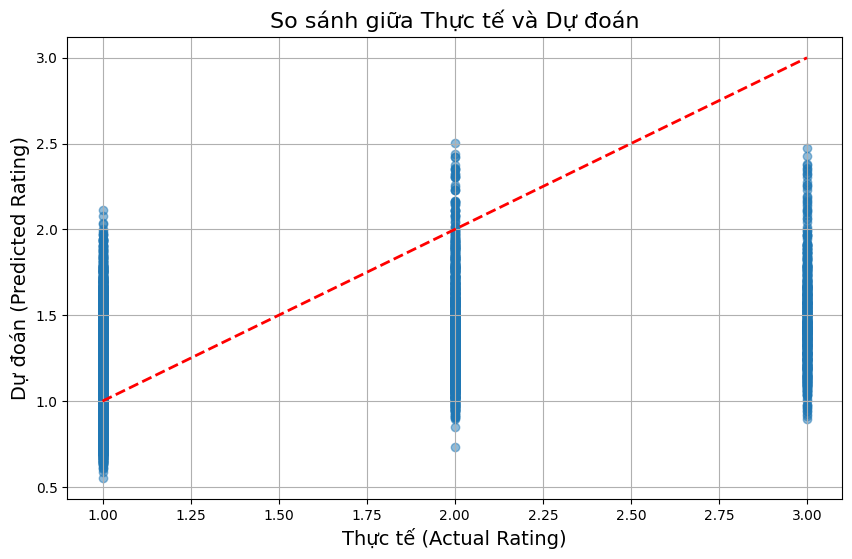

In [41]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ so sánh giữa giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(10, 6))
plt.scatter(actual, predictions, alpha=0.5)
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='red', linewidth=2, linestyle='--')
plt.title('So sánh giữa Thực tế và Dự đoán', fontsize=16)
plt.xlabel('Thực tế (Actual Rating)', fontsize=14)
plt.ylabel('Dự đoán (Predicted Rating)', fontsize=14)
plt.grid(True)
plt.show()


In [42]:
from sklearn.preprocessing import MinMaxScaler

# Kết quả từ Content-based
def get_content_based_recommendations(item_id, svd_df, weight=0.5, top_n=10):
    item_vector = svd_df.loc[item_id].values.reshape(1, -1)
    similarity_scores = cosine_similarity(item_vector, svd_df.values).flatten()
    
    # Lấy top N sản phẩm tương tự
    similar_items = similarity_scores.argsort()[-top_n-1:-1][::-1]
    similar_scores = similarity_scores[similar_items]
    
    return svd_df.index[similar_items], similar_scores * weight

# Kết quả từ Collaborative filtering
import numpy as np

# Hàm gợi ý sản phẩm cho một user_idx cụ thể
def get_collaborative_recommendations(user_idx, user_matrix, item_matrix, weight=0.5, top_n=10):
    # Dự đoán rating cho tất cả sản phẩm
    predicted_ratings = np.dot(user_matrix[user_idx], item_matrix.T)
    
    # Sắp xếp các sản phẩm theo rating dự đoán từ cao đến thấp
    recommended_item_indices = np.argsort(predicted_ratings)[::-1]
    
    # Lấy ra các sản phẩm với rating cao nhất
    recommended_items = recommended_item_indices[:top_n]
    
    return recommended_items, predicted_ratings[recommended_items]



# Kết hợp Content-based và Collaborative filtering
def hybrid_recommendations(user_idx, item_id, svd_df, user_matrix, item_matrix, top_n=10):
    # Lấy kết quả từ từng phương pháp
    content_items, content_scores = get_content_based_recommendations(item_id, svd_df, weight=0.5, top_n=top_n)
    collab_items, collab_scores = get_collaborative_recommendations(user_idx, user_matrix, item_matrix, weight=0.5, top_n=top_n)
    
    # Tổng hợp kết quả
    all_items = list(content_items) + list(collab_items)
    all_scores = list(content_scores) + list(collab_scores)
    
    # Trung bình cộng điểm giữa hai phương pháp
    combined_scores = {}
    for item, score in zip(all_items, all_scores):
        if item in combined_scores:
            combined_scores[item] += score
        else:
            combined_scores[item] = score
    
    # Sắp xếp sản phẩm theo điểm trung bình
    sorted_items = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
    
    # Trả về top N sản phẩm
    return [item for item, score in sorted_items[:top_n]]

# Ví dụ sử dụng

import random

# Giả sử bạn có số lượng người dùng trong user_matrix
num_users = user_matrix.shape[0]  # Số lượng người dùng

# Chọn ngẫu nhiên 3 chỉ số người dùng
user_idxs = random.sample(range(num_users), 3)

# Lấy gợi ý sản phẩm cho từng người dùng ngẫu nhiên
for user_idx in user_idxs:
    top_recommendations = hybrid_recommendations(user_idx, item_id, svd_df, user_matrix, item_matrix, top_n=10)
    print("Gợi ý từ hệ thống hybrid cho User {}:".format(user_idx), top_recommendations)


Gợi ý từ hệ thống hybrid cho User 1572: [511, 2575, 142, 2143, 3292, 2614, 2911, 2516, 3123, 2824]
Gợi ý từ hệ thống hybrid cho User 1999: [3491, 2575, 3386, 2909, 142, 1657, 3100, 2844, 2854, 258]
Gợi ý từ hệ thống hybrid cho User 11041: [2824, 2614, 2575, 2911, 1126, 3123, 2155, 2030, 370, 482]


In [43]:
from sklearn.metrics import mean_squared_error, f1_score
import numpy as np

# Hàm đánh giá với RMSE và F1-Score
def evaluate_hybrid(test_data, svd_df, user_matrix, item_matrix, top_k=10):
    predictions = []
    actual = []
    f1_scores = []

    for _, row in test_data.iterrows():
        user_idx = row['user_idx']
        item_id = row['item_idx']
        
        # Kiểm tra tính hợp lệ
        if item_id not in svd_df.index or user_idx >= user_matrix.shape[0]:
            continue

        # Điểm thực tế
        actual_rating = row['rating']
        actual.append(actual_rating)
        
        # Dự đoán từ hybrid
        recommended_items = hybrid_recommendations(user_idx, item_id, svd_df, user_matrix, item_matrix, top_n=top_k)
        hybrid_score = np.mean([1 if item == item_id else 0 for item in recommended_items])
        predictions.append(hybrid_score)
        
        # Tính F1-score
        predicted_binary = [1 if item in recommended_items else 0 for item in test_data['item_idx']]
        actual_binary = [1 if row['item_idx'] == item else 0 for item in test_data['item_idx']]
        f1 = f1_score(actual_binary, predicted_binary, average='macro')
        f1_scores.append(f1)
    
    # Tính RMSE
    rmse = mean_squared_error(actual, predictions, squared=False) if predictions else float('nan')
    f1_avg = np.mean(f1_scores) if f1_scores else float('nan')
    
    return rmse, f1_avg

# Gọi hàm đánh giá
top_ks = [3, 5, 10]
for top_k in top_ks:
    rmse, f1 = evaluate_hybrid(test_data, svd_df, user_matrix, item_matrix, top_k=top_k)
    print(f"Top-{top_k} Evaluation:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  F1-Score: {f1:.4f}")


Top-3 Evaluation:
  RMSE: 1.2243
  F1-Score: 0.5002
Top-5 Evaluation:
  RMSE: 1.2244
  F1-Score: 0.4999
Top-10 Evaluation:
  RMSE: 1.2246
  F1-Score: 0.4997
